In [5]:
# === Setup ===
!pip -q install pandas numpy scikit-learn matplotlib joblib

import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from joblib import dump

# Folders for outputs
os.makedirs("artifacts", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)


In [6]:
# === Upload & Load ===
print("Upload your CSV/Excel (must have: customer_id, transaction_date, amount)")
uploaded = files.upload()
if not uploaded:
    raise SystemExit("No file uploaded.")

DATA_PATH = list(uploaded.keys())[0]
print("Loaded:", DATA_PATH)

if DATA_PATH.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

print("Raw shape:", df.shape)
display(df.head())


Upload your CSV/Excel (must have: customer_id, transaction_date, amount)


Saving customer_transactions.csv to customer_transactions.csv
Loaded: customer_transactions.csv
Raw shape: (500, 7)


,customer_id,transaction_id,transaction_date,amount,product_category,payment_method,location
0,1065,T1000,04-08-2025 01:11,822.18,Books,Credit Card,Molinaburgh
1,1082,T1001,21-06-2025 07:05,218.61,Groceries,UPI,New Danielfort
2,1061,T1002,03-02-2025 03:37,593.82,Sports,UPI,Thomasberg
3,1085,T1003,06-04-2025 23:14,901.10,Sports,Debit Card,North Michael
4,1073,T1004,07-06-2025 20:15,147.38,Electronics,Credit Card,West Brittany


Columns: ['customer_id', 'transaction_id', 'transaction_date', 'amount', 'product_category', 'payment_method', 'location']

DTypes:
 customer_id           int64
transaction_id       object
transaction_date     object
amount              float64
product_category     object
payment_method       object
location             object
dtype: object

Missing values:
 customer_id         0
transaction_id      0
transaction_date    0
amount              0
product_category    0
payment_method      0
location            0
dtype: int64

Duplicate rows: 0


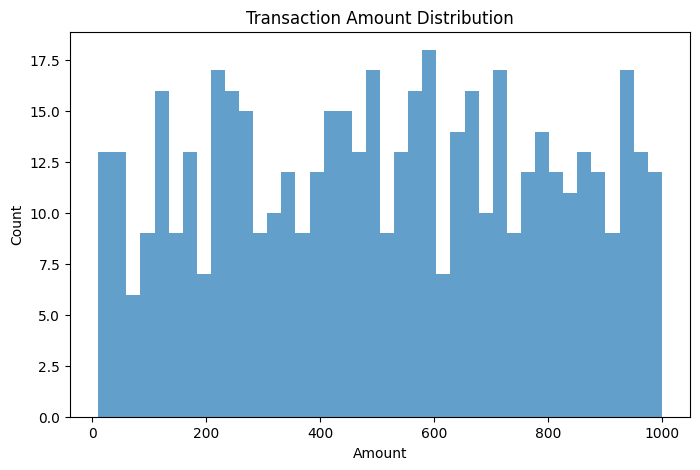


Amount describe:
 count    500.000000
mean     513.629580
std      280.818926
min       10.070000
25%      269.077500
50%      514.320000
75%      753.115000
max      999.250000
Name: amount, dtype: float64


In [7]:
# === Basic EDA ===
print("Columns:", list(df.columns))
print("\nDTypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())

# Amount distribution if present
if "amount" in df.columns:
    s = pd.to_numeric(df["amount"], errors="coerce")
    s.dropna().plot(kind="hist", bins=40, alpha=0.7)
    plt.title("Transaction Amount Distribution")
    plt.xlabel("Amount"); plt.ylabel("Count")
    plt.show()
    print("\nAmount describe:\n", s.describe())


In [4]:
df.head()

,customer_id,transaction_id,transaction_date,amount,product_category,payment_method,location
0,1065,T1000,04-08-2025 01:11,822.18,Books,Credit Card,Molinaburgh
1,1082,T1001,21-06-2025 07:05,218.61,Groceries,UPI,New Danielfort
2,1061,T1002,03-02-2025 03:37,593.82,Sports,UPI,Thomasberg
3,1085,T1003,06-04-2025 23:14,901.10,Sports,Debit Card,North Michael
4,1073,T1004,07-06-2025 20:15,147.38,Electronics,Credit Card,West Brittany


=== Data Quality Report (Raw) ===
Duplicates: 0

Missing values per column:
No missing values.

Outlier scan (IQR method) on numeric columns:
 - customer_id: 0 outliers (outside [951.00, 1151.00])


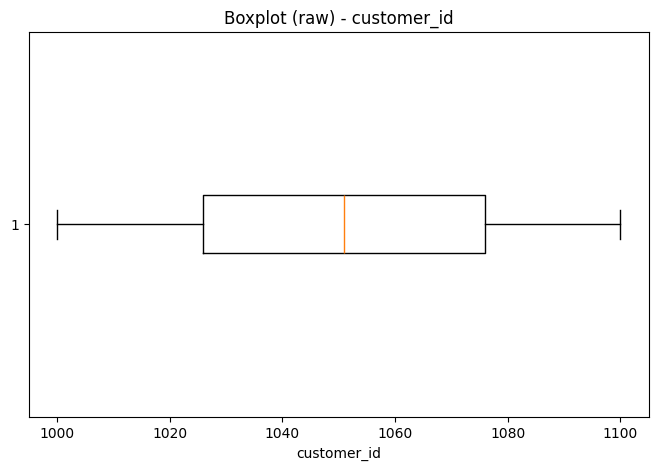

 - amount: 0 outliers (outside [-456.98, 1479.17])


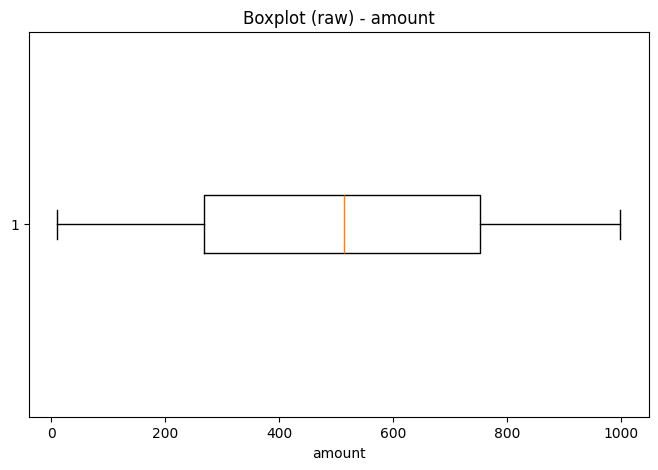

In [8]:
# === Data Quality Checks (raw) ===
print("=== Data Quality Report (Raw) ===")

# 1) Duplicates
dup_count = df.duplicated().sum()
print(f"Duplicates: {dup_count}")

# 2) Nulls per column
nulls = df.isna().sum()
print("\nMissing values per column:")
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values.")

# 3) Outliers (IQR) on numeric columns
num_cols_raw = df.select_dtypes(include=["number"]).columns.tolist()
if len(num_cols_raw):
    print("\nOutlier scan (IQR method) on numeric columns:")
    for col in num_cols_raw:
        col_series = pd.to_numeric(df[col], errors="coerce")
        q1, q3 = col_series.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        outliers = col_series[(col_series < lower) | (col_series > upper)]
        print(f" - {col}: {outliers.count()} outliers (outside [{lower:.2f}, {upper:.2f}])")
        # boxplot
        plt.boxplot(col_series.dropna(), vert=False, whis=1.5)
        plt.title(f"Boxplot (raw) - {col}")
        plt.xlabel(col)
        plt.show()
else:
    print("\nNo numeric columns found for outlier scan.")


In [9]:
# === Clean & RFM ===
# standardize column names
df.columns = [c.strip().lower() for c in df.columns]

# alias mapping
col_map = {}
if "customer_id" not in df.columns:
    for alt in ["customer","cust_id","user_id","client_id","id"]:
        if alt in df.columns: col_map[alt] = "customer_id"; break
if "transaction_date" not in df.columns:
    for alt in ["date","order_date","invoice_date"]:
        if alt in df.columns: col_map[alt] = "transaction_date"; break
if "amount" not in df.columns:
    for alt in ["price","spend","sales","total","revenue","amount_spent","value"]:
        if alt in df.columns: col_map[alt] = "amount"; break
df = df.rename(columns=col_map)

required = {"customer_id","transaction_date","amount"}
missing = required - set(df.columns)
if missing:
    raise SystemExit(f"Missing required columns: {missing}")

# minimal working copy
df_req = df[["customer_id","transaction_date","amount"]].copy()

# typing and cleaning
df_req["transaction_date"] = pd.to_datetime(df_req["transaction_date"], errors="coerce", dayfirst=True)
df_req["amount"] = pd.to_numeric(df_req["amount"], errors="coerce")
df_req = df_req.dropna(subset=["customer_id","transaction_date","amount"]).drop_duplicates()
df_req = df_req[df_req["amount"] >= 0].copy()
df_req["customer_id"] = df_req["customer_id"].astype(str)

print("Cleaned shape:", df_req.shape)
display(df_req.head())

# RFM
reference_date = df_req["transaction_date"].max()
rfm = (df_req.groupby("customer_id")
       .agg(last_purchase=("transaction_date","max"),
            frequency=("transaction_date","count"),
            monetary=("amount","sum"))
       .reset_index())
rfm["recency"] = (reference_date - rfm["last_purchase"]).dt.days
rfm = rfm[["customer_id","recency","frequency","monetary"]].copy()

print("RFM shape:", rfm.shape)
display(rfm.head())


Cleaned shape: (500, 3)


,customer_id,transaction_date,amount
0,1065,2025-08-04 01:11:00,822.18
1,1082,2025-06-21 07:05:00,218.61
2,1061,2025-02-03 03:37:00,593.82
3,1085,2025-04-06 23:14:00,901.10
4,1073,2025-06-07 20:15:00,147.38


RFM shape: (100, 4)


,customer_id,recency,frequency,monetary
0,1000,87,5,2591.29
1,1001,74,4,1824.51
2,1002,23,3,1988.78
3,1003,54,9,3565.34
4,1004,68,7,4345.34


=== Outlier scan (RFM features) ===
 - recency: 4 outliers (outside [-55.38, 129.62])


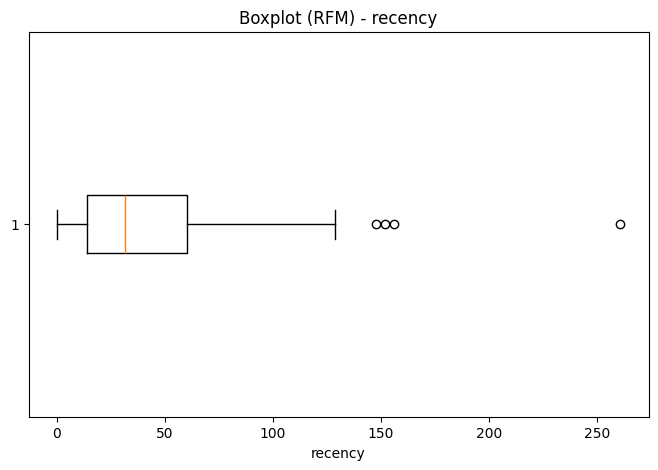

 - frequency: 3 outliers (outside [0.38, 9.38])


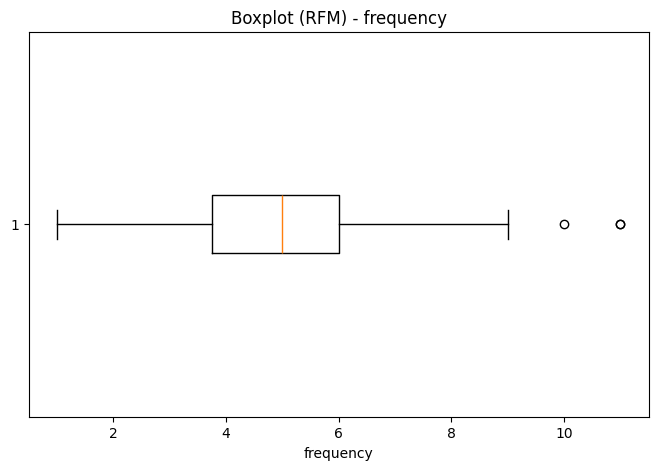

 - monetary: 1 outliers (outside [-790.52, 5901.91])


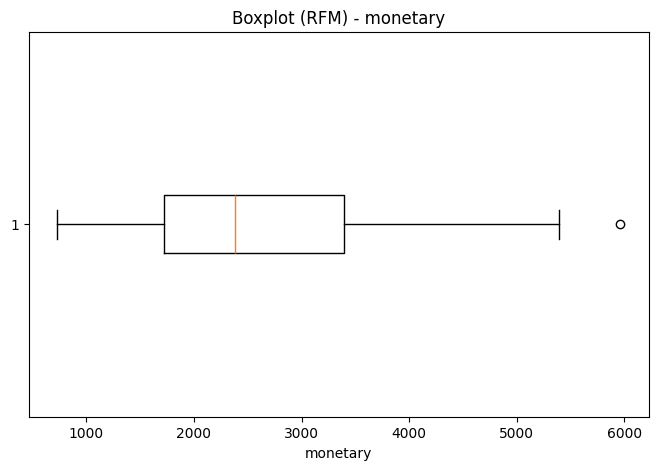

In [10]:
# === Outlier check on RFM features (IQR) ===
print("=== Outlier scan (RFM features) ===")
for col in ["recency","frequency","monetary"]:
    q1, q3 = rfm[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = rfm[(rfm[col] < lower) | (rfm[col] > upper)][col]
    print(f" - {col}: {outliers.count()} outliers (outside [{lower:.2f}, {upper:.2f}])")
    plt.boxplot(rfm[col].dropna(), vert=False, whis=1.5)
    plt.title(f"Boxplot (RFM) - {col}")
    plt.xlabel(col)
    plt.show()

# (Optional) If you want to auto-trim extreme outliers for modeling, uncomment:
# def iqr_trim(df_in, cols, whisker=1.5):
#     keep = pd.Series(True, index=df_in.index)
#     for c in cols:
#         q1, q3 = df_in[c].quantile([0.25, 0.75])
#         iqr = q3 - q1
#         low, high = q1 - whisker*iqr, q3 + whisker*iqr
#         keep &= df_in[c].between(low, high)
#     return df_in[keep].copy()
# rfm = iqr_trim(rfm, ["frequency","monetary"])  # example: trim on F & M


Best K = 2 | Silhouette = 0.3896


,k,silhouette,inertia
0,2,0.389601,167.430688
1,3,0.328772,120.196523
2,4,0.330379,91.394904
3,5,0.345111,72.402553
4,6,0.325916,60.285387
5,7,0.304707,51.735075
6,8,0.305643,44.649252
7,9,0.289760,40.305240
8,10,0.295409,36.651063


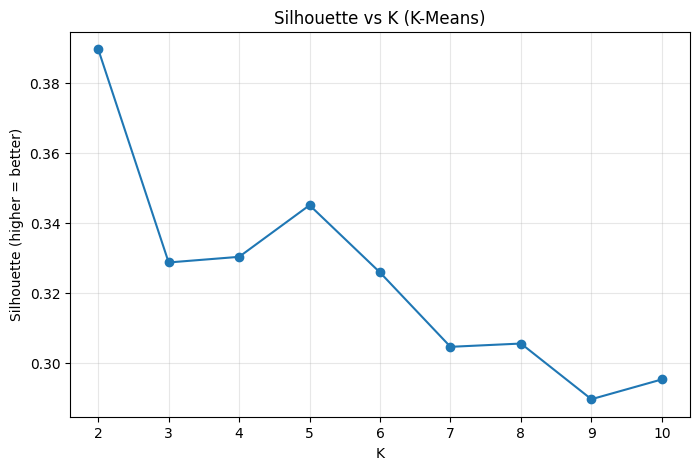

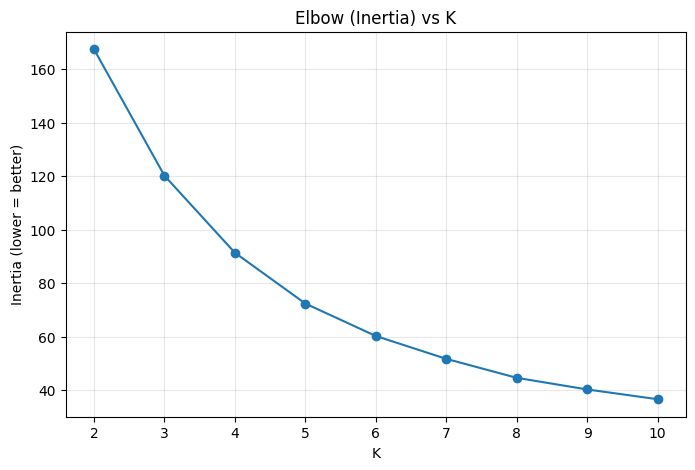

In [11]:
# === Scale & Tune K ===
FEATURES = ["recency","frequency","monetary"]
X = rfm[FEATURES].values
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

def tune_kmeans_silhouette(Xs, k_range=range(2, 11), repeats=5, n_init=10, seed=42):
    rows = []
    for k in k_range:
        sils, inertias = [], []
        for r in range(repeats):
            km = KMeans(n_clusters=k, n_init=n_init, random_state=seed+r)
            labels = km.fit_predict(Xs)
            sils.append(silhouette_score(Xs, labels))
            inertias.append(km.inertia_)
        rows.append({"k": k, "silhouette": float(np.mean(sils)), "inertia": float(np.mean(inertias))})
    grid = pd.DataFrame(rows)
    best_k = int(grid.loc[grid["silhouette"].idxmax(), "k"])
    best_sil = float(grid["silhouette"].max())
    return best_k, best_sil, grid

BEST_K, BEST_SIL, grid = tune_kmeans_silhouette(X_scaled, k_range=range(2, 11), repeats=5)
print(f"Best K = {BEST_K} | Silhouette = {BEST_SIL:.4f}")
display(grid)

# Silhouette vs K
plt.plot(grid["k"], grid["silhouette"], marker="o")
plt.title("Silhouette vs K (K-Means)")
plt.xlabel("K"); plt.ylabel("Silhouette (higher = better)")
plt.grid(True, alpha=0.3)
plt.show()

# Elbow (Inertia) vs K
plt.plot(grid["k"], grid["inertia"], marker="o")
plt.title("Elbow (Inertia) vs K")
plt.xlabel("K"); plt.ylabel("Inertia (lower = better)")
plt.grid(True, alpha=0.3)
plt.show()


Silhouette (K=4): 0.3304


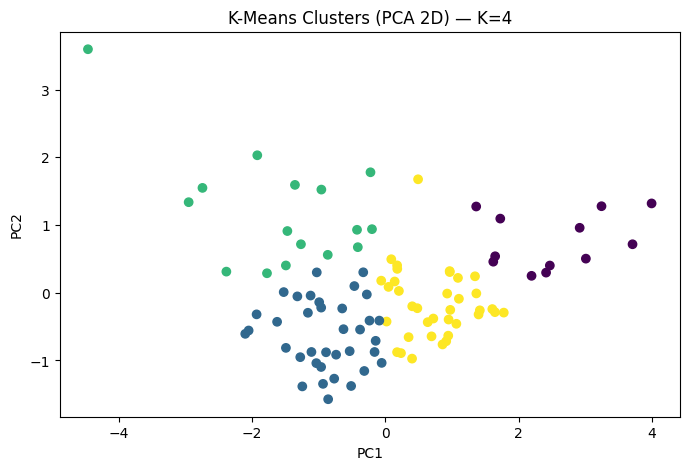

Cluster Summary (K=4):


,cluster,recency,frequency,monetary,Count_Customers
0,0,27.25,8.75,4683.52,12
1,1,36.64,3.56,1645.26,36
2,2,117.44,3.88,1744.68,16
3,3,24.53,5.69,3151.90,36


In [16]:
BEST_K = 4  # <-- force K=4

# 1) Fit model and get labels
kmeans = KMeans(n_clusters=BEST_K, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 2) Quality check at K=4
sil = silhouette_score(X_scaled, labels)
print(f"Silhouette (K=4): {sil:.4f}")

# 3) Attach labels and plot PCA
rfm_final = rfm.copy()
rfm_final["cluster"] = labels

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
rfm_final["pc1"], rfm_final["pc2"] = coords[:, 0], coords[:, 1]

plt.figure()
plt.scatter(rfm_final["pc1"], rfm_final["pc2"], c=rfm_final["cluster"])
plt.title("K-Means Clusters (PCA 2D) — K=4")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

# 4) Summary table (avg R, F, M + counts)
summary = (rfm_final.groupby("cluster")[FEATURES]
           .mean().round(2).reset_index().sort_values("cluster"))
counts = rfm_final["cluster"].value_counts().rename("Count_Customers")
summary = summary.merge(counts, left_on="cluster", right_index=True)

print("Cluster Summary (K=4):")
display(summary)


In [17]:
# 5) (Optional) Save outputs & artifacts for your Flask app
os.makedirs("outputs", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

rfm_final[["customer_id"] + FEATURES + ["cluster"]].to_csv("outputs/rfm_with_clusters.csv", index=False)
summary.to_csv("outputs/cluster_summary.csv", index=False)

dump(scaler, "artifacts/scaler.joblib")
dump(kmeans, "artifacts/kmeans.joblib")
with open("artifacts/feature_cols.json","w") as f:
    json.dump(FEATURES, f)
with open("artifacts/reference_date.json","w") as f:
    json.dump({"reference_date": str(reference_date)}, f)
with open("artifacts/model_meta.json","w") as f:
    json.dump({"model":"kmeans","k": 4}, f)

In [19]:
!zip -r customer_segmentation_results.zip artifacts outputs

from google.colab import files
files.download("customer_segmentation_results.zip")


  adding: artifacts/ (stored 0%)
  adding: artifacts/scaler.joblib (deflated 27%)
  adding: artifacts/kmeans.joblib (deflated 41%)
  adding: artifacts/feature_cols.json (deflated 14%)
  adding: artifacts/model_meta.json (deflated 4%)
  adding: artifacts/reference_date.json (stored 0%)
  adding: outputs/ (stored 0%)
  adding: outputs/rfm_with_clusters.csv (deflated 55%)
  adding: outputs/cluster_summary.csv (deflated 23%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>